# Global Well-Being: Exploring the Relationship Between Mental Health, Economic Factors, and Happiness

## Project Introduction

Mental health and overall well-being are influenced by a complex combination of economic, social, and healthcare factors. Governments and organizations worldwide invest significant resources into improving mental health services, yet disparities remain between countries due to differences in wealth, healthcare infrastructure, and access to treatment.

This project investigates these relationships by combining data from a global mental health dataset with the World Happiness Report. Through data cleaning, exploratory data analysis, visualization, database design, SQL queries, and custom Python programming, the project examines which factors are most strongly associated with national happiness and mental health outcomes.

The analysis was completed using Python, Pandas, SQLite, Matplotlib, and Seaborn as part of the Code:You Keystone Capstone Project.

# Research Question & Hypothesis

## Main Research Question

What factors are most strongly associated with national happiness and mental health outcomes across countries?

## Supporting Research Questions

1. Is there a relationship between GDP per capita and national happiness?

2. Does greater access to mental health care reduce treatment gaps?

3. Is social media use associated with higher rates of depression and anxiety?

4. Which regions experience the greatest mental health challenges?

5. Which factors appear to have the strongest relationship with national happiness?

## Hypothesis

It is expected that countries with stronger economies, greater social support, and more developed mental health systems will generally report higher happiness scores and better mental health outcomes than countries with fewer healthcare resources and larger treatment gaps.

# Data Sources

This project combines two publicly available datasets:

**Global Mental Health Statistics**

This dataset contains information related to depression, anxiety, suicide rates, mental health treatment gaps, psychiatrist availability, healthcare spending, and other indicators describing the state of mental health around the world.

**World Happiness Report**

This dataset contains national happiness scores and contributing factors such as GDP per capita, social support, life expectancy, freedom to make life choices, generosity, and perceptions of corruption.

The datasets were merged using each country's ISO3 country code to create a single dataset for analysis.

# Importing Libraries

The following libraries are used throughout the project for data manipulation, visualization, statistical analysis, and database development.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# SQLite
import sqlite3

# Display graphs inside notebook
%matplotlib inline

# Data Loading

The cleaned dataset is imported into a Pandas DataFrame. Initial inspection is performed to verify that the data loaded correctly before beginning the cleaning and exploratory analysis process.

In [2]:
df = pd.read_csv("../data/cleaned/mental_health_combined.csv")

## Previewing the Dataset

The first few rows of the dataset are displayed to verify that the data has loaded correctly and to provide an initial overview of the available variables.

In [5]:
df.head()

,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per_100k,psychiatrists_per100k,mh_budget_pct_of_health_spending,mh_spend_per_capita_usd,...,data_year,data_source,Overall rank,happiness_score,gdp_per_capita_usd_y,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Malawi,MWI,Africa,Low,3.3,4.5,6.5,0.02,0.8,0.1,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,150.0,3.410,0.191,0.560,0.495,0.443,0.218,0.089
1,Mozambique,MOZ,Africa,Low,3.4,4.6,8.2,0.04,0.6,0.1,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,123.0,4.466,0.204,0.986,0.390,0.494,0.197,0.138
2,Ethiopia,ETH,Africa,Low,3.5,4.8,10.2,0.04,1.0,0.1,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,134.0,4.286,0.336,1.033,0.532,0.344,0.209,0.100
3,Zimbabwe,ZWE,Africa,Low,4.0,5.2,15.4,0.05,0.7,0.1,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,146.0,3.663,0.366,1.114,0.433,0.361,0.151,0.089
4,Tanzania,TZA,Africa,Low,3.6,4.9,8.6,0.04,0.8,0.1,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,153.0,3.231,0.476,0.885,0.499,0.417,0.276,0.147


In [8]:
df.tail()

,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per_100k,psychiatrists_per100k,mh_budget_pct_of_health_spending,mh_spend_per_capita_usd,...,data_year,data_source,Overall rank,happiness_score,gdp_per_capita_usd_y,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
87,Sweden,SWE,Europe,High,4.6,4.8,13.9,26.8,10.2,165.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,7.0,7.343,1.387,1.487,1.009,0.574,0.267,0.373
88,Denmark,DNK,Europe,High,4.7,4.9,11.3,19.4,8.9,178.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,2.0,7.600,1.383,1.573,0.996,0.592,0.252,0.410
89,Singapore,SGP,W. Pacific,High,3.5,4.8,9.2,8.6,6.4,82.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,34.0,6.262,1.572,1.463,1.141,0.556,0.271,0.453
90,Switzerland,CHE,Europe,High,4.4,4.7,12.2,54.9,8.2,320.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,6.0,7.480,1.452,1.526,1.052,0.572,0.263,0.343
91,Norway,NOR,Europe,High,4.5,4.6,12.6,31.0,9.8,210.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,3.0,7.554,1.488,1.582,1.028,0.603,0.271,0.341


In [9]:
df.shape

(92, 37)

In [10]:
df.columns

Index(['country', 'iso3', 'region', 'income_group', 'depression_pct',
       'anxiety_pct', 'suicide_rate_per_100k', 'psychiatrists_per100k',
       'mh_budget_pct_of_health_spending', 'mh_spend_per_capita_usd',
       'treatment_gap_pct', 'social_media_hours_daily',
       'internet_penetration_pct', 'gdp_per_capita_usd_x',
       'population_millions', 'covid_mh_increase_pct', 'youth_mh_crisis_score',
       'has_mh_policy', 'has_mh_law', 'mental_health_crisis_index',
       'total_affected_millions', 'psychiatrists_per_million',
       'mh_investment_gap', 'social_media_mental_health_risk',
       'depression_anxiety_comorbidity_est_pct', 'mh_system_score',
       'income_group_code', 'data_year', 'data_source', 'Overall rank',
       'happiness_score', 'gdp_per_capita_usd_y', 'Social support',
       'Healthy life expectancy', 'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='str')

## Inspecting the Dataset Structure

The dataset structure is examined to identify column names, data types, missing values, and the total number of observations prior to cleaning.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 37 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country                                 92 non-null     str    
 1   iso3                                    92 non-null     str    
 2   region                                  92 non-null     str    
 3   income_group                            92 non-null     str    
 4   depression_pct                          92 non-null     float64
 5   anxiety_pct                             92 non-null     float64
 6   suicide_rate_per_100k                   92 non-null     float64
 7   psychiatrists_per100k                   92 non-null     float64
 8   mh_budget_pct_of_health_spending        92 non-null     float64
 9   mh_spend_per_capita_usd                 92 non-null     float64
 10  treatment_gap_pct                       92 non-null     float64
 11  social

In [12]:
df["has_mh_policy"] = df["has_mh_policy"].astype(bool)

In [13]:
df["has_mh_law"] = df["has_mh_law"].astype(bool)

In [14]:
(df["gdp_per_capita_usd_x"] == df["gdp_per_capita_usd_y"]).all()

np.False_

In [15]:
df[["gdp_per_capita_usd_x", "gdp_per_capita_usd_y"]].describe()

,gdp_per_capita_usd_x,gdp_per_capita_usd_y
count,92.000000,85.000000
mean,22231.608696,1.028612
std,25685.337791,0.330628
min,600.000000,0.191000
25%,3975.000000,0.820000
50%,10150.000000,1.050000
75%,33975.000000,1.301000
max,106900.000000,1.572000


In [16]:
df[[
    "country",
    "gdp_per_capita_usd_x",
    "gdp_per_capita_usd_y"
]].head(10)

,country,gdp_per_capita_usd_x,gdp_per_capita_usd_y
0,Malawi,700,0.191
1,Mozambique,600,0.204
2,Ethiopia,1200,0.336
3,Zimbabwe,1000,0.366
4,Tanzania,1200,0.476
5,Uganda,900,0.332
6,Lesotho,1200,0.489
7,Eswatini,4200,NaN
8,Ukraine,4108,0.820
9,Nigeria,2200,0.696


In [17]:
df = df.rename(columns={
    "gdp_per_capita_usd_x": "gdp_per_capita_usd",
    "gdp_per_capita_usd_y": "happiness_gdp_factor"
})

In [18]:
df = df.rename(columns={
    "Overall rank": "overall_rank",
    "Social support": "social_support",
    "Healthy life expectancy": "healthy_life_expectancy",
    "Freedom to make life choices": "freedom_to_make_life_choices",
    "Perceptions of corruption": "perceptions_of_corruption"
})

## Summary Statistics

Descriptive statistics provide an overview of the distribution, central tendency, and spread of each numerical variable in the dataset.

In [19]:
df.describe()

,depression_pct,anxiety_pct,suicide_rate_per_100k,psychiatrists_per100k,mh_budget_pct_of_health_spending,mh_spend_per_capita_usd,treatment_gap_pct,social_media_hours_daily,internet_penetration_pct,gdp_per_capita_usd,...,income_group_code,data_year,overall_rank,happiness_score,happiness_gdp_factor,social_support,healthy_life_expectancy,freedom_to_make_life_choices,Generosity,perceptions_of_corruption
count,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,...,92.000000,92.0,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,4.402174,5.632609,11.559783,7.182283,3.758696,38.951087,58.934783,2.209783,73.750000,22231.608696,...,2.923913,2025.0,67.917647,5.690247,1.028612,1.287647,0.808824,0.423659,0.182835,0.125165
std,0.754471,1.201657,9.825511,9.485814,2.960366,63.418593,27.884694,0.786711,24.262133,25685.337791,...,1.008030,0.0,45.130027,1.106188,0.330628,0.238595,0.203602,0.125802,0.106557,0.108770
min,2.900000,3.800000,3.200000,0.020000,0.600000,0.100000,17.000000,0.100000,8.000000,600.000000,...,1.000000,2025.0,1.000000,3.231000,0.191000,0.560000,0.168000,0.067000,0.000000,0.005000
25%,3.800000,4.800000,7.575000,0.500000,1.200000,0.725000,26.000000,1.600000,68.750000,3975.000000,...,2.000000,2025.0,26.000000,4.722000,0.820000,1.147000,0.706000,0.351000,0.099000,0.050000
50%,4.400000,5.200000,9.800000,3.150000,2.850000,8.000000,64.500000,2.100000,82.500000,10150.000000,...,3.000000,2025.0,65.000000,5.697000,1.050000,1.360000,0.828000,0.443000,0.160000,0.089000
75%,4.900000,6.100000,12.825000,12.450000,5.650000,49.750000,84.500000,2.800000,92.250000,33975.000000,...,4.000000,2025.0,106.000000,6.444000,1.301000,1.475000,0.987000,0.516000,0.260000,0.161000
max,6.300000,9.300000,87.500000,54.900000,11.300000,320.000000,97.000000,4.800000,99.000000,106900.000000,...,4.000000,2025.0,153.000000,7.769000,1.572000,1.587000,1.141000,0.631000,0.566000,0.453000


In [20]:
df.describe(include="object")

C:\Users\Otters4Life\AppData\Local\Temp\ipykernel_41424\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,country,iso3,region,income_group,social_media_mental_health_risk,data_source
count,92,92,92,92,92,92
unique,92,92,6,4,4,1
top,Malawi,MWI,Europe,High,Moderate (1.5-2.5h),WHO Mental Health Atlas 2024 | GBD Study 2023 ...
freq,1,1,32,35,44,92


In [21]:
df.sample(5)

,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per_100k,psychiatrists_per100k,mh_budget_pct_of_health_spending,mh_spend_per_capita_usd,...,data_year,data_source,overall_rank,happiness_score,happiness_gdp_factor,social_support,healthy_life_expectancy,freedom_to_make_life_choices,Generosity,perceptions_of_corruption
18,Venezuela,VEN,Americas,Upper-Middle,4.6,6.0,8.8,0.7,0.9,0.4,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,108.0,4.707,0.960,1.427,0.805,0.154,0.064,0.047
83,Spain,ESP,Europe,High,4.5,5.0,8.5,10.8,5.2,42.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,30.0,6.354,1.286,1.484,1.062,0.362,0.153,0.079
54,China,CHN,W. Pacific,Upper-Middle,4.0,4.6,8.0,2.2,2.2,4.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,93.0,5.191,1.029,1.125,0.893,0.521,0.058,0.100
56,Hungary,HUN,Europe,High,5.0,5.4,19.1,6.2,3.8,22.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,62.0,5.758,1.201,1.410,0.828,0.199,0.081,0.020
28,Tunisia,TUN,Africa,Lower-Middle,4.3,7.1,3.8,0.8,1.5,1.2,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,124.0,4.461,0.921,1.000,0.815,0.167,0.059,0.055


# Data Cleaning

Before conducting the analysis, the dataset was cleaned to improve consistency and prepare it for exploration. This included inspecting missing values, verifying data types, renaming columns, and confirming that duplicate records were not present.

## Missing Value Analysis

Missing values are identified to determine whether any preprocessing or filtering is required before analysis.

In [22]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

healthy_life_expectancy         7
social_support                  7
happiness_gdp_factor            7
happiness_score                 7
overall_rank                    7
Generosity                      7
freedom_to_make_life_choices    7
perceptions_of_corruption       7
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 37 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country                                 92 non-null     str    
 1   iso3                                    92 non-null     str    
 2   region                                  92 non-null     str    
 3   income_group                            92 non-null     str    
 4   depression_pct                          92 non-null     float64
 5   anxiety_pct                             92 non-null     float64
 6   suicide_rate_per_100k                   92 non-null     float64
 7   psychiatrists_per100k                   92 non-null     float64
 8   mh_budget_pct_of_health_spending        92 non-null     float64
 9   mh_spend_per_capita_usd                 92 non-null     float64
 10  treatment_gap_pct                       92 non-null     float64
 11  social

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
depression_pct,92.0,4.402174,0.754471,2.900,3.8000,4.4000,4.9000,6.300
anxiety_pct,92.0,5.632609,1.201657,3.800,4.8000,5.2000,6.1000,9.300
suicide_rate_per_100k,92.0,11.559783,9.825511,3.200,7.5750,9.8000,12.8250,87.500
psychiatrists_per100k,92.0,7.182283,9.485814,0.020,0.5000,3.1500,12.4500,54.900
mh_budget_pct_of_health_spending,92.0,3.758696,2.960366,0.600,1.2000,2.8500,5.6500,11.300
mh_spend_per_capita_usd,92.0,38.951087,63.418593,0.100,0.7250,8.0000,49.7500,320.000
treatment_gap_pct,92.0,58.934783,27.884694,17.000,26.0000,64.5000,84.5000,97.000
social_media_hours_daily,92.0,2.209783,0.786711,0.100,1.6000,2.1000,2.8000,4.800
internet_penetration_pct,92.0,73.750000,24.262133,8.000,68.7500,82.5000,92.2500,99.000
gdp_per_capita_usd,92.0,22231.608696,25685.337791,600.000,3975.0000,10150.0000,33975.0000,106900.000


# Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to better understand the dataset, identify patterns, detect outliers, and explore relationships between variables before answering the research questions.

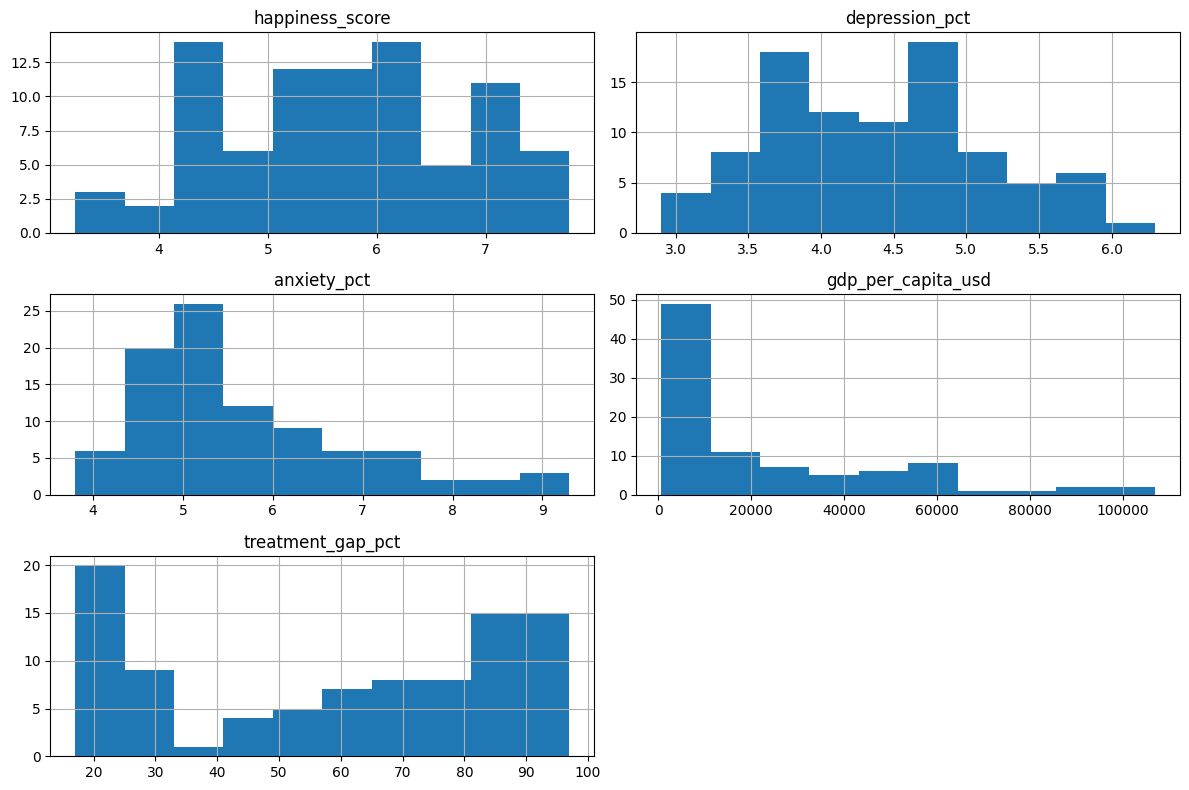

In [26]:
columns = [
    "happiness_score",
    "depression_pct",
    "anxiety_pct",
    "gdp_per_capita_usd",
    "treatment_gap_pct"
]

df[columns].hist(figsize=(12,8))
plt.tight_layout()

Text(0.5, 1.0, 'GDP per Capita Distribution')

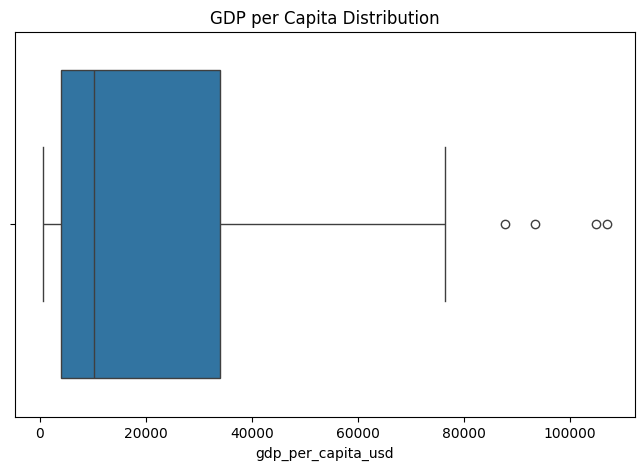

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["gdp_per_capita_usd"]
)

plt.title("GDP per Capita Distribution")

Text(0.5, 1.0, 'Depression Percentage Distribution')

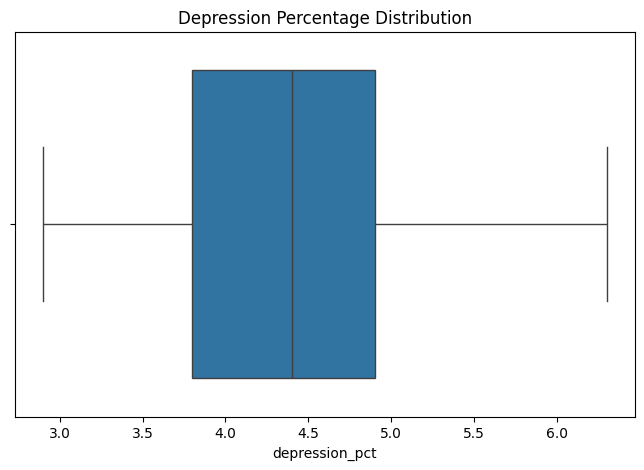

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["depression_pct"]
)

plt.title("Depression Percentage Distribution")

Text(0.5, 1.0, 'Anxiety Percentage Distribution')

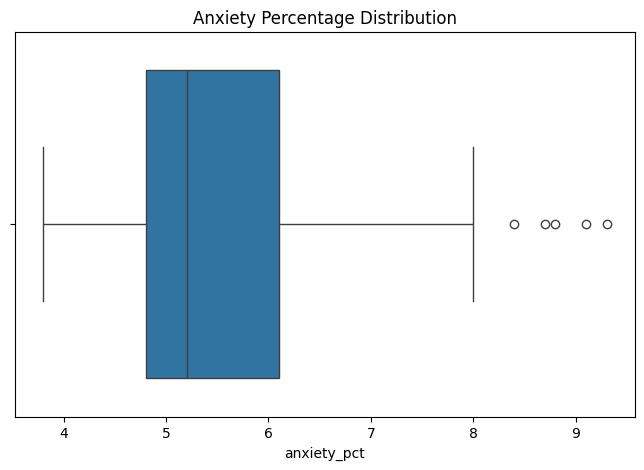

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["anxiety_pct"]
)

plt.title("Anxiety Percentage Distribution")

Text(0.5, 1.0, 'Treatment Gap Percentage Distribution')

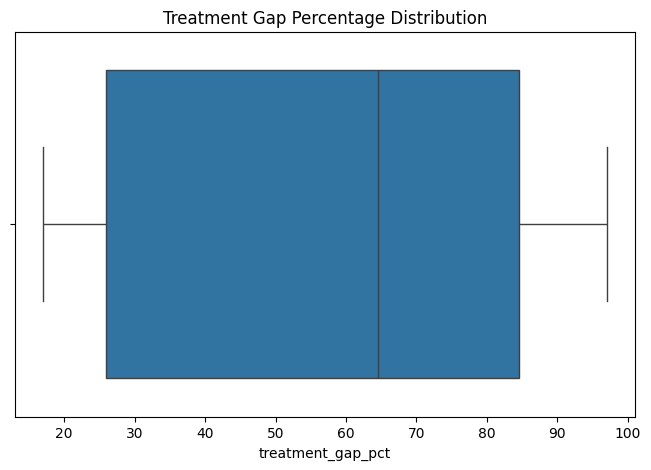

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["treatment_gap_pct"]
)

plt.title("Treatment Gap Percentage Distribution")

In [31]:
numeric_df = df.select_dtypes(include="number")

In [32]:
corr = numeric_df.corr()

Text(0.5, 1.0, 'Correlation Matrix')

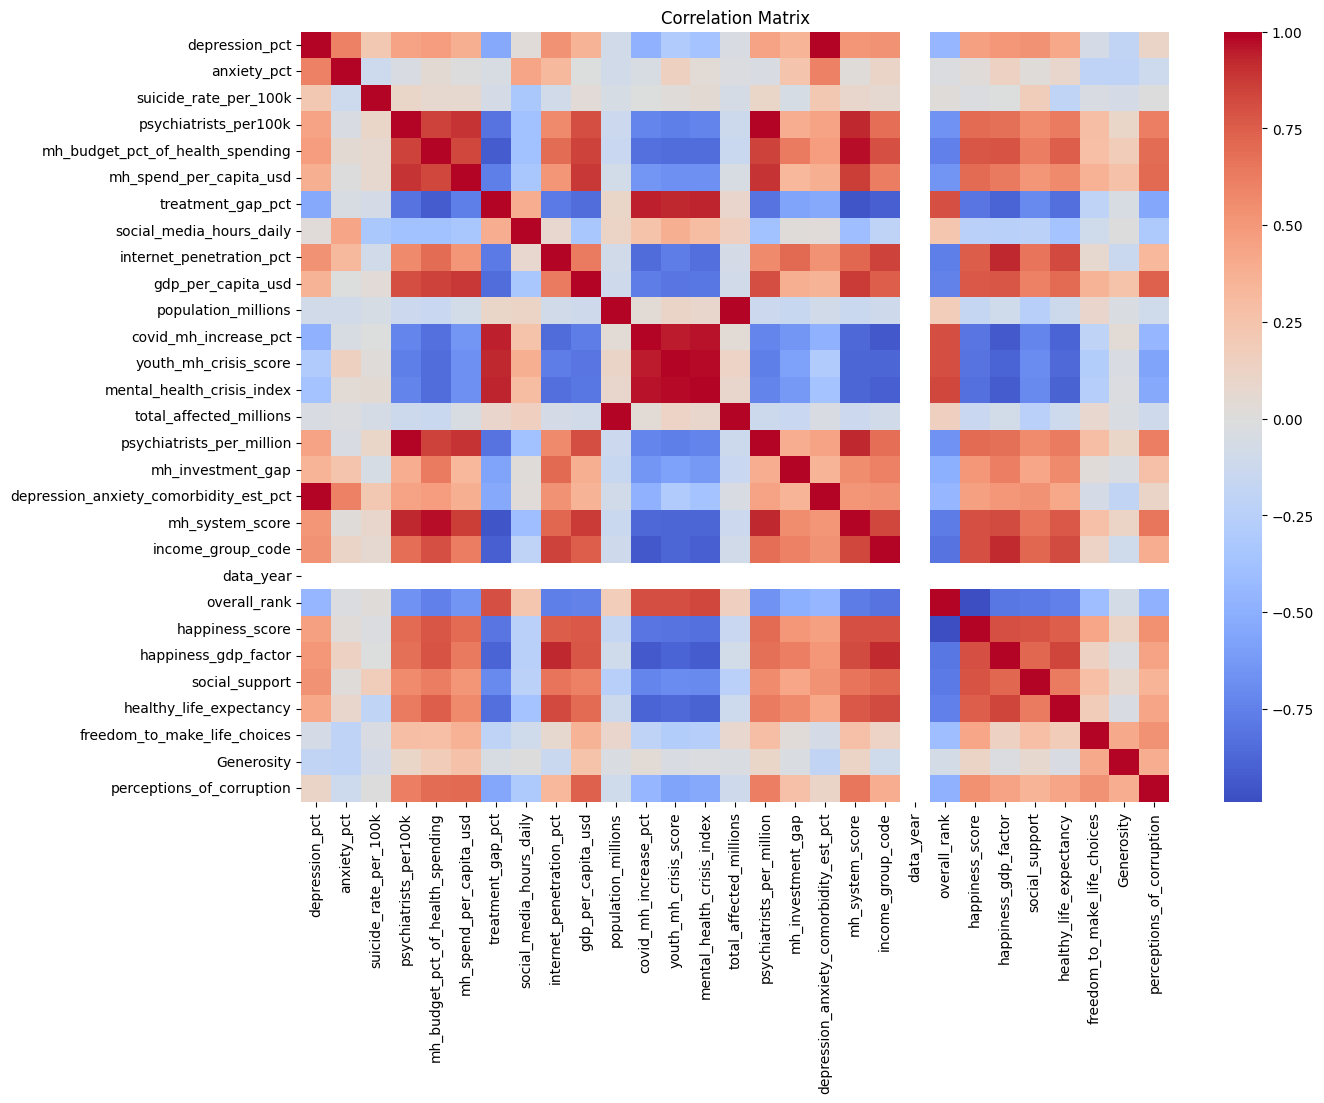

In [33]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

The exploratory analysis showed that the merged dataset is generally clean and suitable for analysis. No duplicate records were found, and data types were appropriate for their respective variables. Seven countries were missing data from the World Happiness Report, resulting in missing values across several happiness-related variables. Initial visualizations revealed variation in GDP per capita, treatment gap percentages, and happiness scores, with some expected outliers among high-income countries. These observations will guide the subsequent data cleaning and analysis steps.

# 5. Research Questions

This section explores the relationships between mental health, economic indicators, healthcare resources, and national happiness. Each research question is investigated using descriptive statistics and visualizations to identify trends and patterns within the dataset.

# Research Question 1

## Is there a relationship between GDP per capita and national happiness?

Economic prosperity is often associated with quality of life, but wealth alone may not determine how happy a population is. This analysis investigates whether countries with higher GDP per capita tend to report higher happiness scores.

In [34]:
df[["country", "gdp_per_capita_usd", "happiness_score"]].head()

,country,gdp_per_capita_usd,happiness_score
0,Malawi,700,3.410
1,Mozambique,600,4.466
2,Ethiopia,1200,4.286
3,Zimbabwe,1000,3.663
4,Tanzania,1200,3.231


In [35]:
df[["gdp_per_capita_usd", "happiness_score"]].isnull().sum()

gdp_per_capita_usd    0
happiness_score       7
dtype: int64

In [36]:
gdp_happiness = df[["gdp_per_capita_usd", "happiness_score"]].dropna()

In [37]:
gdp_happiness.describe()

,gdp_per_capita_usd,happiness_score
count,85.000000,85.000000
mean,23150.682353,5.690247
std,26105.406237,1.106188
min,600.000000,3.231000
25%,4000.000000,4.722000
50%,11200.000000,5.697000
75%,34800.000000,6.444000
max,106900.000000,7.769000


The GDP per capita values vary substantially across countries, indicating a wide range of economic conditions. Happiness scores also show noticeable variation, suggesting meaningful differences in reported well-being between countries.

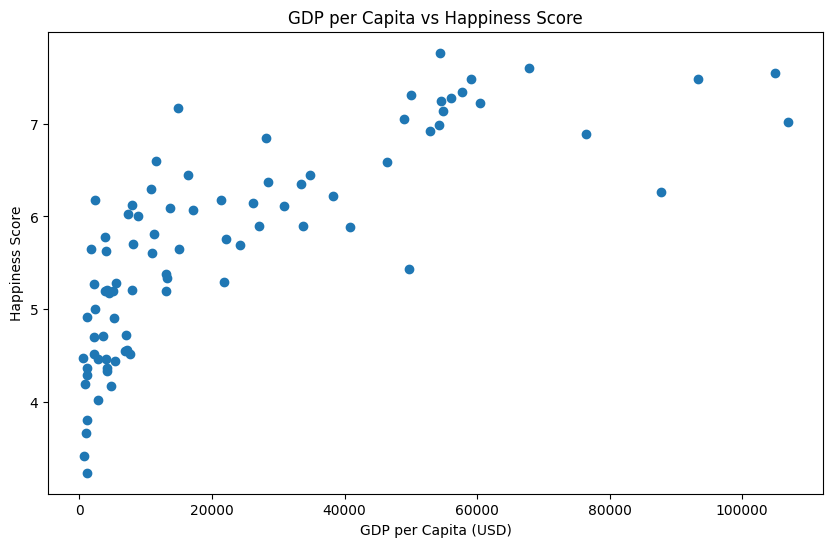

In [38]:
plt.figure(figsize=(10,6))

plt.scatter(
    gdp_happiness["gdp_per_capita_usd"],
    gdp_happiness["happiness_score"]
)

plt.title("GDP per Capita vs Happiness Score")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Happiness Score")

plt.show()

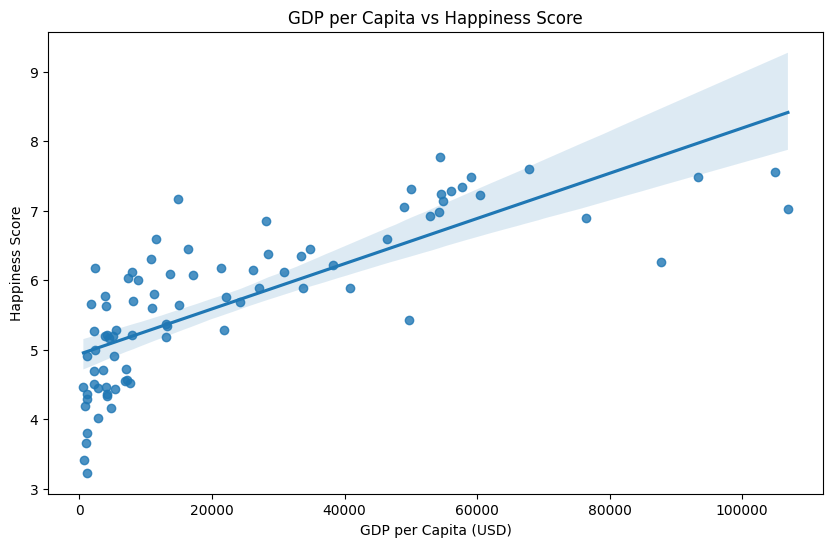

In [39]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=gdp_happiness,
    x="gdp_per_capita_usd",
    y="happiness_score"
)

plt.title("GDP per Capita vs Happiness Score")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Happiness Score")

plt.show()

In [40]:
correlation = gdp_happiness["gdp_per_capita_usd"].corr(
    gdp_happiness["happiness_score"]
)

print(correlation)

0.7678234008133268


| Correlation     | Interpretation            |
| --------------- | ------------------------- |
| 0.90–1.00       | Very strong positive      |
| 0.70–0.89       | Strong positive           |
| 0.50–0.69       | Moderate positive         |
| 0.30–0.49       | Weak positive             |
| 0.00–0.29       | Little or no relationship |
| Negative values | Inverse relationship      |


In [41]:
df.nlargest(10, "happiness_score")[
    ["country", "gdp_per_capita_usd", "happiness_score"]
]

,country,gdp_per_capita_usd,happiness_score
82,Finland,54400,7.769
88,Denmark,67900,7.600
91,Norway,104900,7.554
86,Netherlands,59100,7.488
90,Switzerland,93400,7.480
87,Sweden,57700,7.343
70,New Zealand,50100,7.307
77,Canada,56100,7.278
84,Austria,54600,7.246
72,Australia,60400,7.228


In [42]:
df.nlargest(10, "gdp_per_capita_usd")[
    ["country", "gdp_per_capita_usd", "happiness_score"]
]

,country,gdp_per_capita_usd,happiness_score
81,Ireland,106900,7.021
91,Norway,104900,7.554
90,Switzerland,93400,7.480
89,Singapore,87800,6.262
59,United States,76400,6.892
88,Denmark,67900,7.600
72,Australia,60400,7.228
86,Netherlands,59100,7.488
87,Sweden,57700,7.343
77,Canada,56100,7.278


The scatter plot demonstrates a positive relationship between GDP per capita and national happiness. Countries with higher GDP per capita generally report higher happiness scores, although the relationship is not perfect.

The calculated correlation coefficient of 0.77 indicates a strong positive relationship between the two variables. This suggests that economic prosperity is associated with greater national happiness, but additional factors such as social support, healthcare, and personal freedoms may also contribute to overall well-being.

Overall, the findings support the idea that wealth contributes to national happiness. However, the presence of countries with similar GDP levels but different happiness scores suggests that economic prosperity alone does not fully explain well-being.

# Research Question 2

## Does greater access to mental health care reduce treatment gaps?

Access to mental health services is an important factor in ensuring people receive the care they need. This section investigates whether countries with greater mental health resources, such as more psychiatrists and higher mental health spending, tend to have smaller treatment gaps.

In [43]:
df[[
    "psychiatrists_per100k",
    "mh_spend_per_capita_usd",
    "treatment_gap_pct"
]].describe()

,psychiatrists_per100k,mh_spend_per_capita_usd,treatment_gap_pct
count,92.000000,92.000000,92.000000
mean,7.182283,38.951087,58.934783
std,9.485814,63.418593,27.884694
min,0.020000,0.100000,17.000000
25%,0.500000,0.725000,26.000000
50%,3.150000,8.000000,64.500000
75%,12.450000,49.750000,84.500000
max,54.900000,320.000000,97.000000


In [44]:
df[[
    "psychiatrists_per100k",
    "mh_spend_per_capita_usd",
    "treatment_gap_pct"
]].isnull().sum()

psychiatrists_per100k      0
mh_spend_per_capita_usd    0
treatment_gap_pct          0
dtype: int64

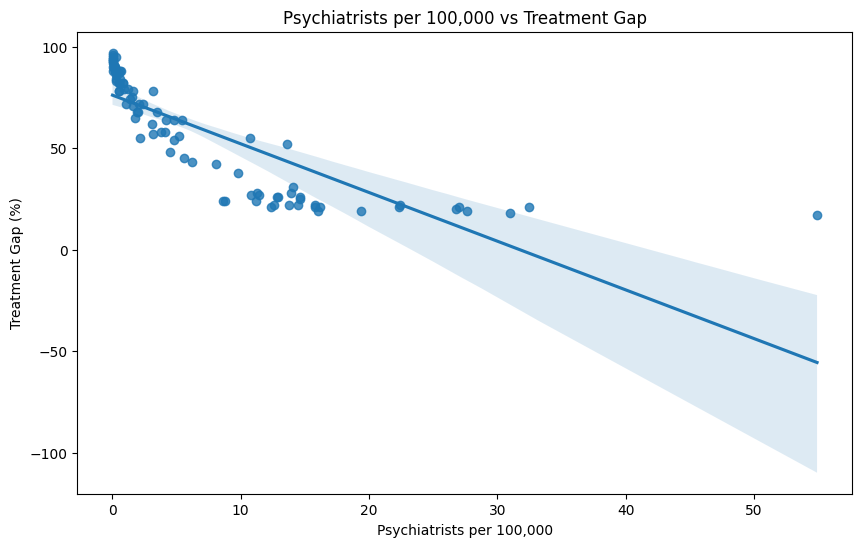

In [45]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="psychiatrists_per100k",
    y="treatment_gap_pct"
)

plt.title("Psychiatrists per 100,000 vs Treatment Gap")
plt.xlabel("Psychiatrists per 100,000")
plt.ylabel("Treatment Gap (%)")

plt.show()

In [46]:
corr_psych = df["psychiatrists_per100k"].corr(
    df["treatment_gap_pct"]
)

print(corr_psych)

-0.8157152024249674


A strong negative correlation was observed between the number of psychiatrists per 100,000 people and the treatment gap percentage. Countries with more psychiatrists generally experienced lower treatment gaps, suggesting that greater availability of mental health professionals may improve access to care.

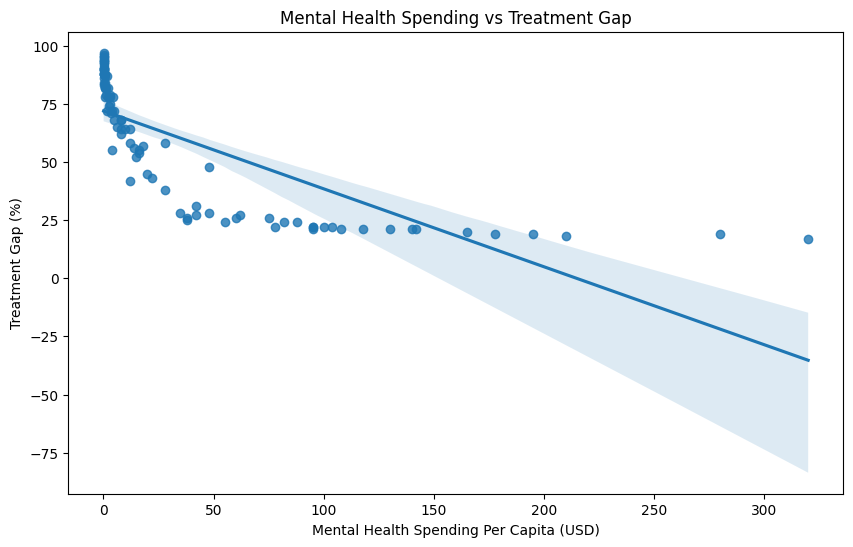

In [47]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="mh_spend_per_capita_usd",
    y="treatment_gap_pct"
)

plt.title("Mental Health Spending vs Treatment Gap")
plt.xlabel("Mental Health Spending Per Capita (USD)")
plt.ylabel("Treatment Gap (%)")

plt.show()

In [48]:
corr_spending = df["mh_spend_per_capita_usd"].corr(
    df["treatment_gap_pct"]
)

print(corr_spending)

-0.7623376961069612


In [49]:
income_gap = (
    df.groupby("income_group")["treatment_gap_pct"]
      .mean()
      .sort_values()
)

income_gap

income_group
High            27.142857
Upper-Middle    66.652174
Lower-Middle    84.038462
Low             94.250000
Name: treatment_gap_pct, dtype: float64

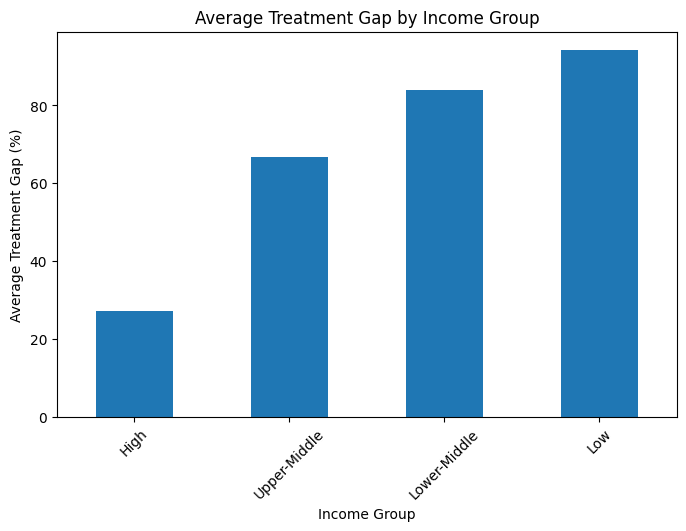

In [50]:
plt.figure(figsize=(8,5))

income_gap.plot(kind="bar")

plt.title("Average Treatment Gap by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Treatment Gap (%)")

plt.xticks(rotation=45)

plt.show()

In [51]:
df.nsmallest(
    10,
    "treatment_gap_pct"
)[[
    "country",
    "psychiatrists_per100k",
    "mh_spend_per_capita_usd",
    "treatment_gap_pct"
]]

,country,psychiatrists_per100k,mh_spend_per_capita_usd,treatment_gap_pct
90,Switzerland,54.9,320.0,17.0
91,Norway,31.0,210.0,18.0
59,United States,16.0,280.0,19.0
82,Finland,27.6,195.0,19.0
88,Denmark,19.4,178.0,19.0
87,Sweden,26.8,165.0,20.0
70,New Zealand,12.4,95.0,21.0
75,Belgium,32.5,130.0,21.0
77,Canada,16.2,140.0,21.0
84,Austria,22.3,108.0,21.0


In [52]:
df.nlargest(
    10,
    "treatment_gap_pct"
)[[
    "country",
    "psychiatrists_per100k",
    "mh_spend_per_capita_usd",
    "treatment_gap_pct"
]]

,country,psychiatrists_per100k,mh_spend_per_capita_usd,treatment_gap_pct
0,Malawi,0.02,0.1,97.0
1,Mozambique,0.04,0.1,96.0
2,Ethiopia,0.04,0.1,95.0
10,North Korea,0.30,0.1,95.0
3,Zimbabwe,0.05,0.1,94.0
4,Tanzania,0.04,0.1,94.0
5,Uganda,0.08,0.1,93.0
6,Lesotho,0.05,0.2,93.0
7,Eswatini,0.08,0.2,92.0
11,Ghana,0.10,0.2,91.0


The analysis suggests that countries with greater access to mental health resources generally experience smaller treatment gaps. Both the number of psychiatrists per 100,000 people and mental health spending per capita showed a negative relationship with treatment gap percentage, indicating that greater investment in mental health care may improve access to treatment.

When comparing countries by income group, higher-income countries generally exhibited smaller treatment gaps than lower-income countries. This finding suggests that economic resources may play an important role in expanding access to mental health services.

In [53]:
correlations = pd.DataFrame({
    "Variable": [
        "Psychiatrists per 100k",
        "Mental Health Spending"
    ],
    "Correlation with Treatment Gap": [
        corr_psych,
        corr_spending
    ]
})

correlations

,Variable,Correlation with Treatment Gap
0,Psychiatrists per 100k,-0.815715
1,Mental Health Spending,-0.762338


# Research Question 3

## Is social media use associated with higher rates of depression and anxiety?

Social media has become a major part of daily life, and many researchers have investigated its potential effects on mental health. This analysis explores whether countries with higher average daily social media usage also report higher rates of depression and anxiety.

It is important to note that this analysis examines correlation rather than causation. Any observed relationships do not necessarily mean that social media causes changes in mental health outcomes.

In [54]:
df[[
    "social_media_hours_daily",
    "depression_pct",
    "anxiety_pct"
]].describe()

,social_media_hours_daily,depression_pct,anxiety_pct
count,92.000000,92.000000,92.000000
mean,2.209783,4.402174,5.632609
std,0.786711,0.754471,1.201657
min,0.100000,2.900000,3.800000
25%,1.600000,3.800000,4.800000
50%,2.100000,4.400000,5.200000
75%,2.800000,4.900000,6.100000
max,4.800000,6.300000,9.300000


In [55]:
df[[
    "social_media_hours_daily",
    "depression_pct",
    "anxiety_pct"
]].isnull().sum()

social_media_hours_daily    0
depression_pct              0
anxiety_pct                 0
dtype: int64

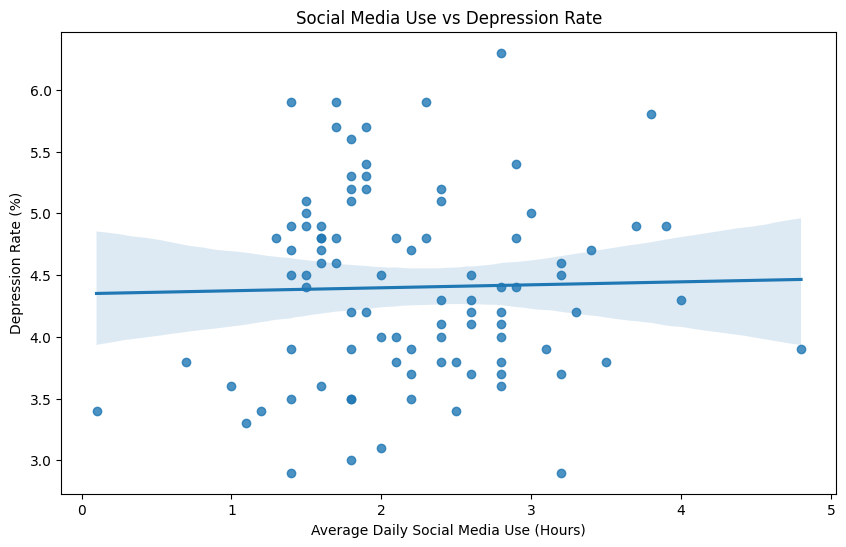

In [56]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="social_media_hours_daily",
    y="depression_pct"
)

plt.title("Social Media Use vs Depression Rate")
plt.xlabel("Average Daily Social Media Use (Hours)")
plt.ylabel("Depression Rate (%)")

plt.show()

In [57]:
corr_depression = df["social_media_hours_daily"].corr(
    df["depression_pct"]
)

print(corr_depression)

0.025142860399407843


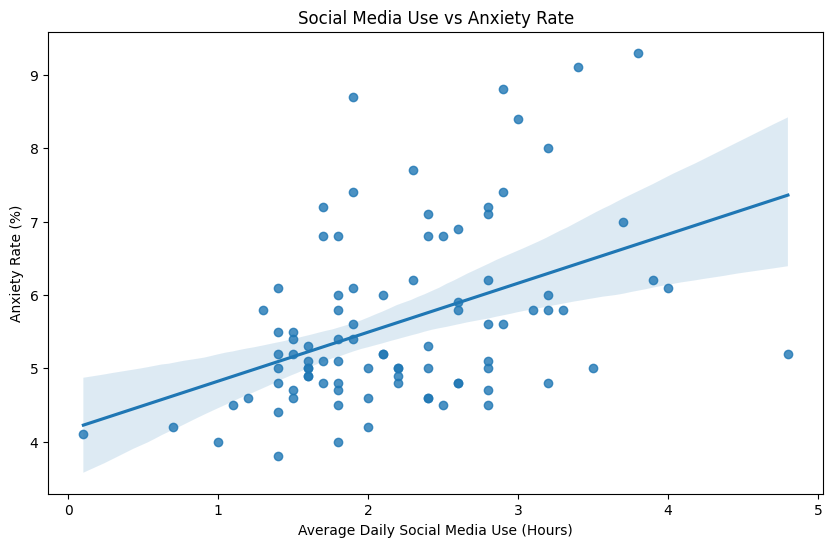

In [58]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="social_media_hours_daily",
    y="anxiety_pct"
)

plt.title("Social Media Use vs Anxiety Rate")
plt.xlabel("Average Daily Social Media Use (Hours)")
plt.ylabel("Anxiety Rate (%)")

plt.show()

In [59]:
corr_anxiety = df["social_media_hours_daily"].corr(
    df["anxiety_pct"]
)

print(corr_anxiety)

0.43661224980558483


In [60]:
comparison = pd.DataFrame({
    "Mental Health Outcome": [
        "Depression",
        "Anxiety"
    ],
    "Correlation": [
        corr_depression,
        corr_anxiety
    ]
})

comparison

,Mental Health Outcome,Correlation
0,Depression,0.025143
1,Anxiety,0.436612


The analysis found virtually no linear relationship between average daily social media use and national depression rates (r = 0.025). This suggests that differences in social media usage alone do not explain variations in depression prevalence across the countries included in this study.

The analysis produced different results for depression and anxiety. Average daily social media use showed almost no relationship with national depression rates (r = 0.025), indicating that countries with greater social media use did not consistently report higher levels of depression.

In contrast, a moderate positive correlation was observed between social media use and anxiety rates (r = 0.437). Countries with higher average social media use generally tended to report higher anxiety rates. Although this relationship is not strong enough to imply causation, it suggests that social media use may be associated with anxiety more than with depression in this dataset.

In [61]:
df.groupby("social_media_mental_health_risk")[[
    "depression_pct",
    "anxiety_pct",
    "social_media_hours_daily"
]].mean().round(2)

,depression_pct,anxiety_pct,social_media_hours_daily
social_media_mental_health_risk,,,
High (2.5-3.5h),4.27,6.16,2.93
Low (<1.5h),4.25,4.86,1.26
Moderate (1.5-2.5h),4.50,5.52,1.98
Very High (>3.5h),4.76,6.76,4.04


The relationship between social media use and mental health differed depending on the outcome being examined. Average daily social media use showed virtually no linear relationship with national depression rates (r = 0.025). Additionally, average depression rates remained relatively stable across the four social media risk categories, suggesting that higher levels of social media use were not consistently associated with greater depression.

In contrast, anxiety demonstrated a moderate positive relationship with social media use (r = 0.437). Average anxiety rates increased steadily across each social media risk category, rising from 4.86% in the low-risk group to 6.76% in the very high-risk group. These findings suggest that greater social media use may be more closely associated with anxiety than with depression.

While these results identify meaningful associations, they do not establish causation. Other social, economic, and healthcare factors may also influence national mental health outcomes.

In [63]:
df.nlargest(
    10,
    "social_media_hours_daily"
)[[
    "country",
    "social_media_hours_daily",
    "depression_pct",
    "anxiety_pct"
]]

,country,social_media_hours_daily,depression_pct,anxiety_pct
9,Nigeria,4.8,3.9,5.2
32,Philippines,4.0,4.3,6.1
21,South Africa,3.9,4.9,6.2
17,Brazil,3.8,5.8,9.3
37,Colombia,3.7,4.9,7.0
12,Kenya,3.5,3.8,5.0
31,Iran,3.4,4.7,9.1
41,Mexico,3.3,4.2,5.8
18,Venezuela,3.2,4.6,6.0
29,Indonesia,3.2,3.7,4.8


In [64]:
df["social_media_mental_health_risk"].value_counts()

social_media_mental_health_risk
Moderate (1.5-2.5h)    44
High (2.5-3.5h)        25
Low (<1.5h)            18
Very High (>3.5h)       5
Name: count, dtype: int64

In [65]:
df.groupby(
    "social_media_mental_health_risk"
)[[
    "depression_pct",
    "anxiety_pct"
]].mean()

,depression_pct,anxiety_pct
social_media_mental_health_risk,,
High (2.5-3.5h),4.272000,6.164000
Low (<1.5h),4.250000,4.855556
Moderate (1.5-2.5h),4.497727,5.520455
Very High (>3.5h),4.760000,6.760000


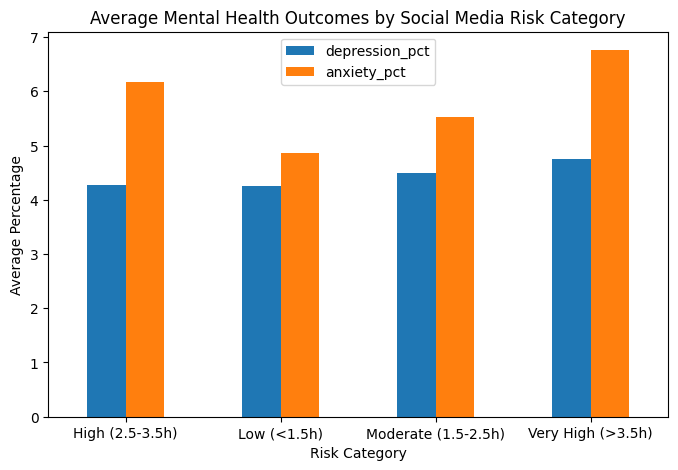

In [66]:
risk = df.groupby(
    "social_media_mental_health_risk"
)[[
    "depression_pct",
    "anxiety_pct"
]].mean()

risk.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Mental Health Outcomes by Social Media Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Percentage")

plt.xticks(rotation=0)

plt.show()

The analysis found a positive relationship between average daily social media use and both depression and anxiety rates. Countries with greater social media usage generally tended to report higher rates of depression and anxiety.

However, the observed relationships varied in strength, and several countries did not follow the overall trend. These exceptions suggest that additional factors beyond social media use likely contribute to national mental health outcomes.

Because this analysis is based on observational data, the results demonstrate association rather than causation.

The findings suggest that social media use may be one factor associated with national mental health outcomes. However, mental health is influenced by many interconnected economic, social, and healthcare factors, so social media use should be considered alongside these broader influences rather than as an isolated explanation.

# Research Question 4

## Which regions experience the greatest mental health challenges?

Mental health outcomes can vary across regions due to differences in economic development, healthcare infrastructure, cultural attitudes, and public policy. This section compares average mental health indicators across world regions to identify regional trends and differences.

In [67]:
df["region"].value_counts()

region
Europe        32
Africa        14
W. Pacific    13
Americas      13
S-E Asia      11
E. Med         9
Name: count, dtype: int64

In [68]:
regional_stats = (
    df.groupby("region")[[
        "depression_pct",
        "anxiety_pct",
        "suicide_rate_per_100k",
        "mental_health_crisis_index"
    ]]
    .mean()
    .round(2)
)

regional_stats

,depression_pct,anxiety_pct,suicide_rate_per_100k,mental_health_crisis_index
region,,,,
Africa,3.95,5.40,16.59,78.21
Americas,4.81,6.53,9.68,59.08
E. Med,4.26,7.23,5.39,61.00
Europe,4.87,5.42,13.00,48.31
S-E Asia,3.85,5.12,8.40,65.55
W. Pacific,3.90,4.83,11.42,52.62


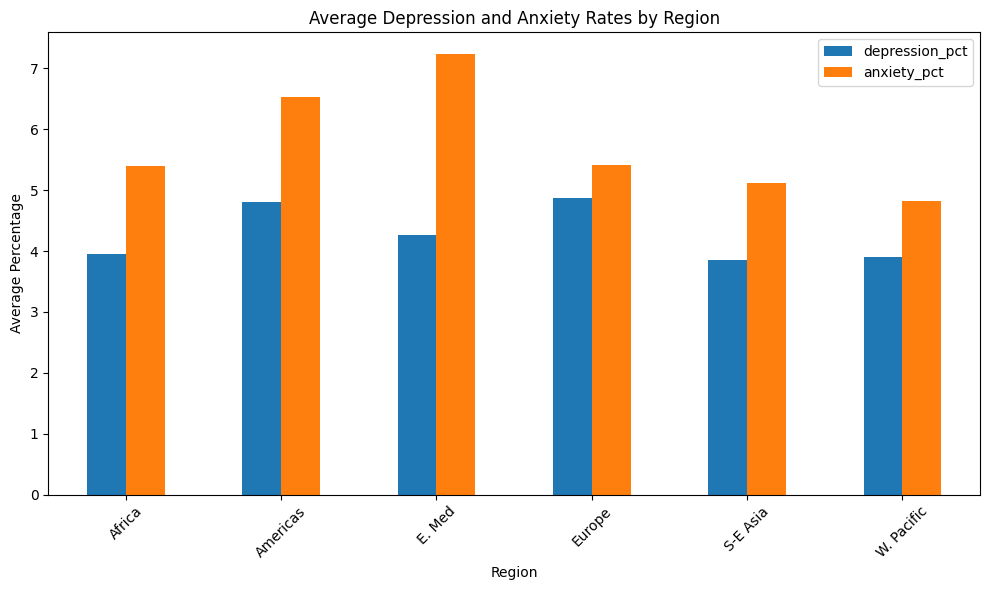

In [70]:
regional_stats[[
    "depression_pct",
    "anxiety_pct"
]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Depression and Anxiety Rates by Region")
plt.xlabel("Region")
plt.ylabel("Average Percentage")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

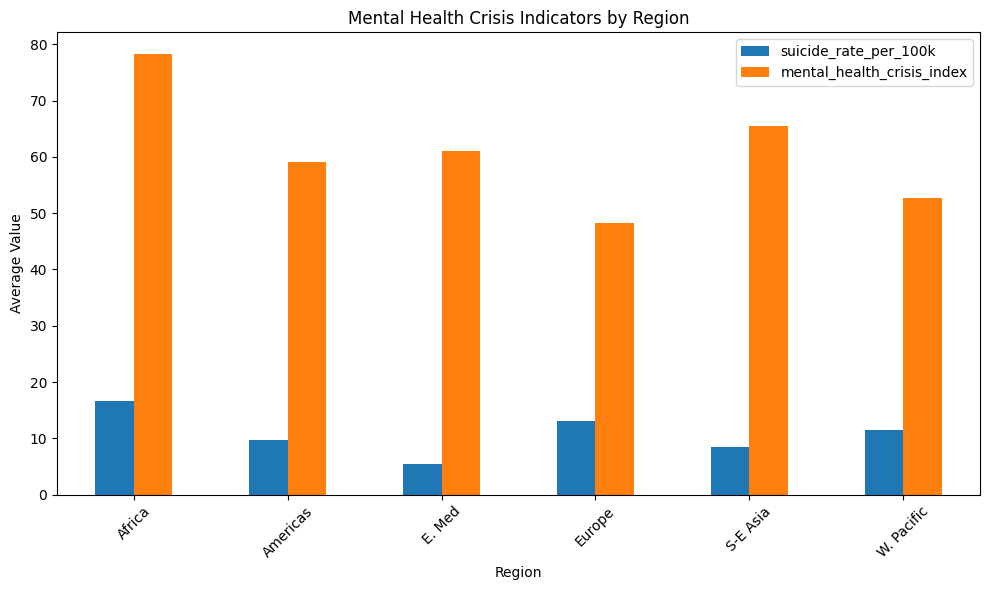

In [71]:
regional_stats[[
    "suicide_rate_per_100k",
    "mental_health_crisis_index"
]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Mental Health Crisis Indicators by Region")
plt.xlabel("Region")
plt.ylabel("Average Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [72]:
resources = (
    df.groupby("region")[[
        "psychiatrists_per100k",
        "mh_spend_per_capita_usd",
        "treatment_gap_pct"
    ]]
    .mean()
    .round(2)
)

resources

,psychiatrists_per100k,mh_spend_per_capita_usd,treatment_gap_pct
region,,,
Africa,0.18,0.39,91.50
Americas,5.52,38.48,61.38
E. Med,3.03,17.99,67.78
Europe,14.46,72.68,37.31
S-E Asia,0.54,1.32,81.82
W. Pacific,6.96,44.28,49.15


Regional analysis revealed noticeable differences in mental health outcomes across the world. Some regions consistently reported higher average depression, anxiety, and mental health crisis scores than others.

Differences in access to mental health resources were also observed. Regions with greater numbers of psychiatrists and higher mental health spending generally tended to have lower treatment gaps, although the relationship was not consistent across all regions.

These findings suggest that regional economic and healthcare differences may contribute to variations in mental health outcomes.

The regional comparisons demonstrate that mental health outcomes are influenced by broader social and economic contexts rather than a single factor. This supports the overall goal of the project by showing that national well-being is shaped by multiple interconnected influences, including healthcare resources, economic development, and regional characteristics.

In [73]:
summary = (
    df.groupby("region")
    .agg({
        "happiness_score": "mean",
        "depression_pct": "mean",
        "anxiety_pct": "mean",
        "psychiatrists_per100k": "mean",
        "treatment_gap_pct": "mean"
    })
    .round(2)
)

summary

,happiness_score,depression_pct,anxiety_pct,psychiatrists_per100k,treatment_gap_pct
region,,,,,
Africa,4.32,3.95,5.40,0.18,91.50
Americas,6.26,4.81,6.53,5.52,61.38
E. Med,5.30,4.26,7.23,3.03,67.78
Europe,6.28,4.87,5.42,14.46,37.31
S-E Asia,4.92,3.85,5.12,0.54,81.82
W. Pacific,6.10,3.90,4.83,6.96,49.15


# Research Question 5

## Which factors appear to have the strongest relationship with national happiness?

National happiness is influenced by many interconnected factors, including economic conditions, mental health, healthcare access, and social well-being. This section examines which variables in the dataset are most strongly associated with happiness scores to better understand the factors that contribute to overall well-being.

In [75]:
happiness_analysis = (
    df[[
        "happiness_score",
        "gdp_per_capita_usd",
        "social_support",
        "healthy_life_expectancy",
        "freedom_to_make_life_choices",
        "Generosity",
        "perceptions_of_corruption",
        "depression_pct",
        "anxiety_pct",
        "treatment_gap_pct",
        "psychiatrists_per100k",
        "mh_spend_per_capita_usd",
        "mh_system_score",
    ]]
    .dropna()
)

In [76]:
happiness_analysis.head()

,happiness_score,gdp_per_capita_usd,social_support,healthy_life_expectancy,freedom_to_make_life_choices,Generosity,perceptions_of_corruption,depression_pct,anxiety_pct,treatment_gap_pct,psychiatrists_per100k,mh_spend_per_capita_usd,mh_system_score
0,3.410,700,0.560,0.495,0.443,0.218,0.089,3.3,4.5,97.0,0.02,0.1,3.4
1,4.466,600,0.986,0.390,0.494,0.197,0.138,3.4,4.6,96.0,0.04,0.1,3.1
2,4.286,1200,1.033,0.532,0.344,0.209,0.100,3.5,4.8,95.0,0.04,0.1,4.7
3,3.663,1000,1.114,0.433,0.361,0.151,0.089,4.0,5.2,94.0,0.05,0.1,4.1
4,3.231,1200,0.885,0.499,0.417,0.276,0.147,3.6,4.9,94.0,0.04,0.1,4.4


In [77]:
happiness_analysis.describe()

,happiness_score,gdp_per_capita_usd,social_support,healthy_life_expectancy,freedom_to_make_life_choices,Generosity,perceptions_of_corruption,depression_pct,anxiety_pct,treatment_gap_pct,psychiatrists_per100k,mh_spend_per_capita_usd,mh_system_score
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,5.690247,23150.682353,1.287647,0.808824,0.423659,0.182835,0.125165,4.485882,5.721176,57.517647,7.613176,41.418824,34.354118
std,1.106188,26105.406237,0.238595,0.203602,0.125802,0.106557,0.108770,0.705109,1.190147,27.948342,9.710830,65.219745,27.846525
min,3.231000,600.000000,0.560000,0.168000,0.067000,0.000000,0.005000,3.300000,4.000000,17.000000,0.020000,0.100000,3.100000
25%,4.722000,4000.000000,1.147000,0.706000,0.351000,0.099000,0.050000,3.900000,4.900000,26.000000,0.500000,0.800000,10.300000
50%,5.697000,11200.000000,1.360000,0.828000,0.443000,0.160000,0.089000,4.500000,5.300000,64.000000,3.200000,8.000000,24.200000
75%,6.444000,34800.000000,1.475000,0.987000,0.516000,0.260000,0.161000,4.900000,6.200000,83.000000,12.800000,60.000000,56.600000
max,7.769000,106900.000000,1.587000,1.141000,0.631000,0.566000,0.453000,6.300000,9.300000,97.000000,54.900000,320.000000,100.000000


In [78]:
corr = happiness_analysis.corr()

corr

,happiness_score,gdp_per_capita_usd,social_support,healthy_life_expectancy,freedom_to_make_life_choices,Generosity,perceptions_of_corruption,depression_pct,anxiety_pct,treatment_gap_pct,psychiatrists_per100k,mh_spend_per_capita_usd,mh_system_score
happiness_score,1.000000,0.767823,0.783114,0.749043,0.431166,0.116064,0.538494,0.462930,0.024802,-0.805090,0.702813,0.701960,0.799609
gdp_per_capita_usd,0.767823,1.000000,0.608081,0.699642,0.361741,0.254759,0.742094,0.363843,-0.062234,-0.853912,0.814921,0.878066,0.875864
social_support,0.783114,0.608081,1.000000,0.630962,0.279314,0.073362,0.352911,0.526195,0.018876,-0.703741,0.561294,0.516194,0.659183
healthy_life_expectancy,0.749043,0.699642,0.630962,1.000000,0.191629,-0.037219,0.435652,0.420923,0.085883,-0.839672,0.633731,0.571736,0.772980
freedom_to_make_life_choices,0.431166,0.361741,0.279314,0.191629,1.000000,0.414992,0.530413,-0.067588,-0.211549,-0.210016,0.285683,0.363462,0.271759
Generosity,0.116064,0.254759,0.073362,-0.037219,0.414992,1.000000,0.391965,-0.195934,-0.207937,-0.047748,0.099250,0.263942,0.115002
perceptions_of_corruption,0.538494,0.742094,0.352911,0.435652,0.530413,0.391965,1.000000,0.113917,-0.113674,-0.547324,0.616939,0.706941,0.651522
depression_pct,0.462930,0.363843,0.526195,0.420923,-0.067588,-0.195934,0.113917,1.000000,0.580431,-0.536910,0.432227,0.374027,0.511375
anxiety_pct,0.024802,-0.062234,0.018876,0.085883,-0.211549,-0.207937,-0.113674,0.580431,1.000000,0.020389,-0.092687,-0.046642,-0.043413
treatment_gap_pct,-0.805090,-0.853912,-0.703741,-0.839672,-0.210016,-0.047748,-0.547324,-0.536910,0.020389,1.000000,-0.814080,-0.764309,-0.955800


In [79]:
happiness_corr = (
    corr["happiness_score"]
    .sort_values(ascending=False)
)

happiness_corr

happiness_score                 1.000000
mh_system_score                 0.799609
social_support                  0.783114
gdp_per_capita_usd              0.767823
healthy_life_expectancy         0.749043
psychiatrists_per100k           0.702813
mh_spend_per_capita_usd         0.701960
perceptions_of_corruption       0.538494
depression_pct                  0.462930
freedom_to_make_life_choices    0.431166
Generosity                      0.116064
anxiety_pct                     0.024802
treatment_gap_pct              -0.805090
Name: happiness_score, dtype: float64

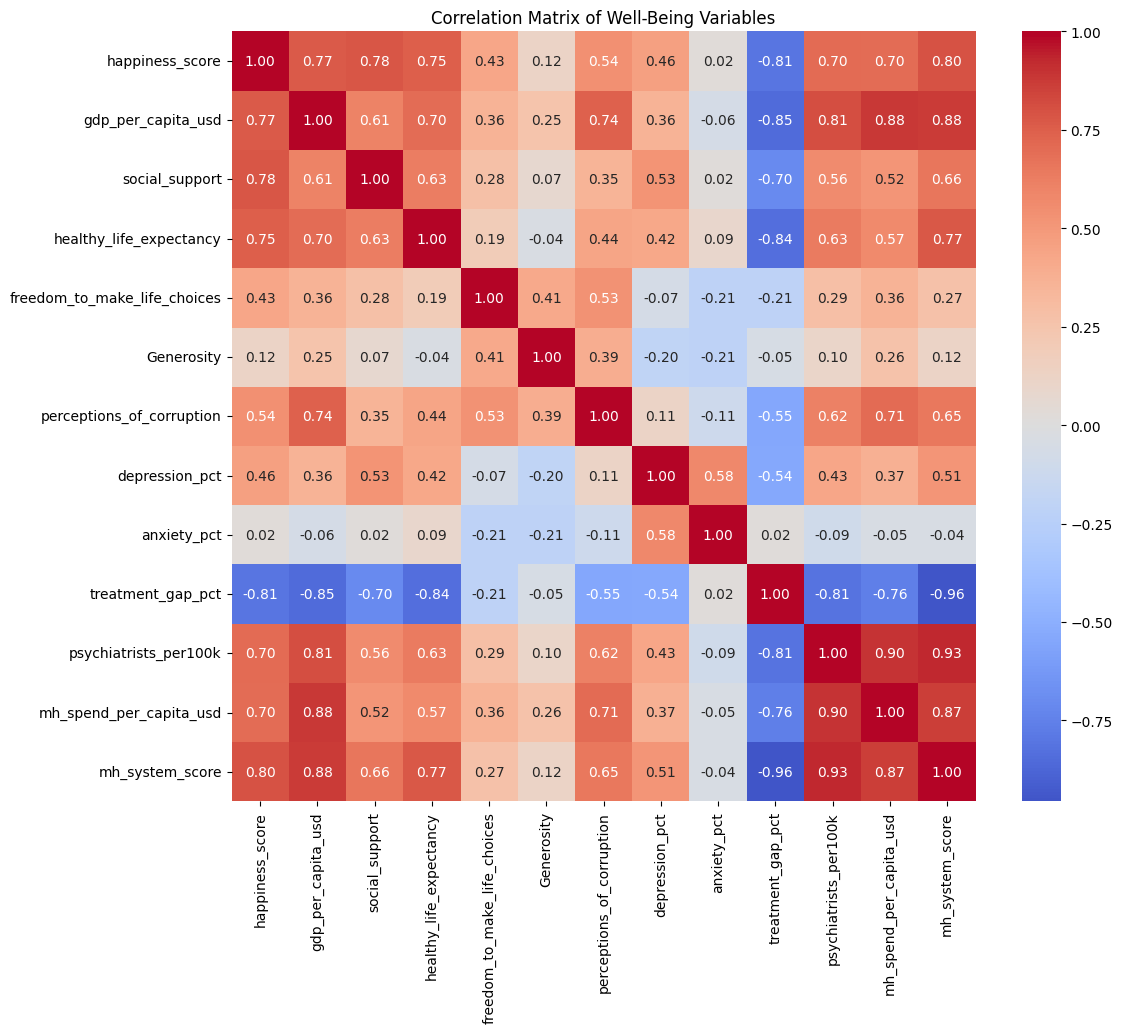

In [80]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix of Well-Being Variables")

plt.show()

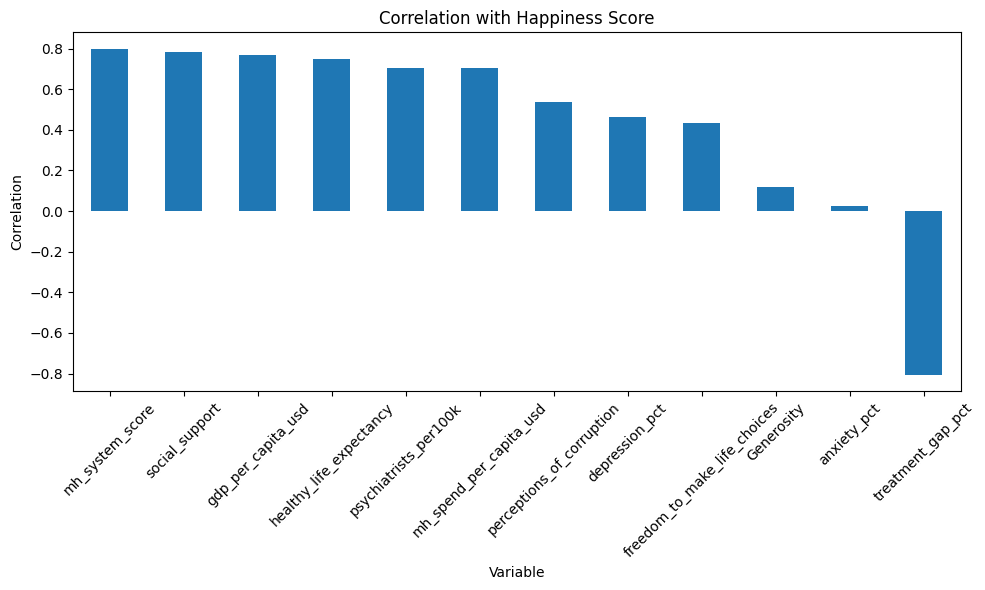

In [81]:
happiness_corr.drop("happiness_score").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Correlation with Happiness Score")
plt.xlabel("Variable")
plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [82]:
happiness_corr.head(6)

happiness_score            1.000000
mh_system_score            0.799609
social_support             0.783114
gdp_per_capita_usd         0.767823
healthy_life_expectancy    0.749043
psychiatrists_per100k      0.702813
Name: happiness_score, dtype: float64

In [83]:
happiness_corr.tail()

depression_pct                  0.462930
freedom_to_make_life_choices    0.431166
Generosity                      0.116064
anxiety_pct                     0.024802
treatment_gap_pct              -0.805090
Name: happiness_score, dtype: float64

Overall, the analysis suggests that national happiness is influenced by a combination of economic, social, and mental health factors rather than a single variable.

Countries with stronger economies, greater social support, healthier populations, and more developed mental health systems generally reported higher happiness scores. Conversely, higher treatment gaps and poorer mental health outcomes were associated with lower happiness.

These findings support the hypothesis that well-being is multidimensional and depends on the interaction of economic resources, healthcare access, and social conditions.

In [84]:
summary = (
    happiness_corr.drop("happiness_score")
    .reset_index()
)

summary.columns = ["Variable", "Correlation with Happiness"]

summary

,Variable,Correlation with Happiness
0,mh_system_score,0.799609
1,social_support,0.783114
2,gdp_per_capita_usd,0.767823
3,healthy_life_expectancy,0.749043
4,psychiatrists_per100k,0.702813
5,mh_spend_per_capita_usd,0.701960
6,perceptions_of_corruption,0.538494
7,depression_pct,0.462930
8,freedom_to_make_life_choices,0.431166
9,Generosity,0.116064


In [85]:
conn = sqlite3.connect("../data/mental_health_combined.db")

In [86]:
cursor = conn.cursor()

In [87]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS Countries (
    iso3 TEXT PRIMARY KEY,
    country TEXT,
    region TEXT,
    income_group TEXT,
    income_group_code INTEGER,
    population_millions REAL
);
""")

In [88]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS Mental_Health (
    mental_health_id INTEGER PRIMARY KEY AUTOINCREMENT,
    iso3 TEXT,

    depression_pct REAL,
    anxiety_pct REAL,
    suicide_rate_per100k REAL,
    treatment_gap_pct REAL,
    mental_health_crisis_index REAL,
    youth_mh_crisis_score REAL,
    total_affected_millions REAL,
    depression_anxiety_comorbidity_est_pct REAL,
    social_media_hours_daily REAL,
    social_media_mental_health_risk TEXT,
    internet_penetration_pct REAL,
    covid_mh_increase_pct REAL,

    FOREIGN KEY (iso3)
        REFERENCES Countries(iso3)
);
""")

In [89]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS Mental_Health_Resources (
    resource_id INTEGER PRIMARY KEY AUTOINCREMENT,
    iso3 TEXT,

    psychiatrists_per100k REAL,
    psychiatrists_per_million REAL,
    mh_budget_pct_of_health_spending REAL,
    mh_spend_per_capita_usd REAL,
    mh_system_score REAL,
    mh_investment_gap REAL,
    has_mh_policy INTEGER,
    has_mh_law INTEGER,

    FOREIGN KEY (iso3)
        REFERENCES Countries(iso3)
);
""")

In [90]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS Happiness (
    happiness_id INTEGER PRIMARY KEY AUTOINCREMENT,
    iso3 TEXT,

    overall_rank INTEGER,
    happiness_score REAL,
    gdp_per_capita_usd REAL,
    happiness_gdp_factor REAL,
    social_support REAL,
    healthy_life_expectancy REAL,
    freedom_to_make_life_choices REAL,
    generosity REAL,
    perceptions_of_corruption REAL,
    data_year INTEGER,
    data_source TEXT,

    FOREIGN KEY (iso3)
        REFERENCES Countries(iso3)
);
""")

In [91]:
conn.commit()

In [92]:
cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table';
""")

cursor.fetchall()

[('Countries',),
 ('Mental_Health',),
 ('sqlite_sequence',),
 ('Mental_Health_Resources',),
 ('Happiness',)]

In [93]:
conn.close()

In [95]:
conn = sqlite3.connect("../data/mental_health_combined.db")

In [96]:
countries_df = df[[
    "iso3",
    "country",
    "region",
    "income_group",
    "income_group_code",
    "population_millions"
]]

In [98]:
mental_health_df = df[[
    "iso3",
    "depression_pct",
    "anxiety_pct",
    "suicide_rate_per_100k",
    "treatment_gap_pct",
    "mental_health_crisis_index",
    "youth_mh_crisis_score",
    "total_affected_millions",
    "depression_anxiety_comorbidity_est_pct",
    "social_media_hours_daily",
    "social_media_mental_health_risk",
    "internet_penetration_pct",
    "covid_mh_increase_pct"
]]

In [99]:
resources_df = df[[
    "iso3",
    "psychiatrists_per100k",
    "psychiatrists_per_million",
    "mh_budget_pct_of_health_spending",
    "mh_spend_per_capita_usd",
    "mh_system_score",
    "mh_investment_gap",
    "has_mh_policy",
    "has_mh_law"
]]

In [101]:
happiness_df = df[[
    "iso3",
    "overall_rank",
    "happiness_score",
    "gdp_per_capita_usd",
    "happiness_gdp_factor",
    "social_support",
    "healthy_life_expectancy",
    "freedom_to_make_life_choices",
    "Generosity",
    "perceptions_of_corruption",
    "data_year",
    "data_source"
]]

In [102]:
countries_df.to_sql(
    "Countries",
    conn,
    if_exists="append",
    index=False
)

92

In [104]:
# Rename the column so it matches the SQLite schema created earlier
mental_health_df = mental_health_df.rename(
    columns={"suicide_rate_per_100k": "suicide_rate_per100k"}
)

mental_health_df.to_sql(
    "Mental_Health",
    conn,
    if_exists="append",
    index=False
)

conn.commit()

In [105]:
resources_df.to_sql(
    "Mental_Health_Resources",
    conn,
    if_exists="append",
    index=False
)

92

In [106]:
happiness_df.to_sql(
    "Happiness",
    conn,
    if_exists="append",
    index=False
)

92

In [107]:
pd.read_sql("""
SELECT *
FROM Countries
LIMIT 5;
""", conn)

,iso3,country,region,income_group,income_group_code,population_millions
0,MWI,Malawi,Africa,Low,1,20.4
1,MOZ,Mozambique,Africa,Low,1,32.8
2,ETH,Ethiopia,Africa,Low,1,123.4
3,ZWE,Zimbabwe,Africa,Low,1,15.9
4,TZA,Tanzania,Africa,Low,1,65.5


In [108]:
pd.read_sql("""
SELECT *
FROM Mental_Health
LIMIT 5;
""", conn)

,mental_health_id,iso3,depression_pct,anxiety_pct,suicide_rate_per100k,treatment_gap_pct,mental_health_crisis_index,youth_mh_crisis_score,total_affected_millions,depression_anxiety_comorbidity_est_pct,social_media_hours_daily,social_media_mental_health_risk,internet_penetration_pct,covid_mh_increase_pct
0,1,MWI,3.3,4.5,6.5,97.0,87.0,9.5,1.59,1.65,1.1,Low (<1.5h),16.0,86.0
1,2,MOZ,3.4,4.6,8.2,96.0,86.0,9.4,2.62,1.70,1.2,Low (<1.5h),18.0,85.0
2,3,ETH,3.5,4.8,10.2,95.0,84.0,9.3,10.24,1.75,1.4,Low (<1.5h),22.0,82.0
3,4,ZWE,4.0,5.2,15.4,94.0,83.0,9.3,1.46,2.00,2.1,Moderate (1.5-2.5h),35.0,82.0
4,5,TZA,3.6,4.9,8.6,94.0,82.0,9.2,5.57,1.80,1.6,Moderate (1.5-2.5h),28.0,80.0


In [109]:
pd.read_sql("""
SELECT *
FROM Mental_Health_Resources
LIMIT 5;
""", conn)

,resource_id,iso3,psychiatrists_per100k,psychiatrists_per_million,mh_budget_pct_of_health_spending,mh_spend_per_capita_usd,mh_system_score,mh_investment_gap,has_mh_policy,has_mh_law
0,1,MWI,0.02,0.2,0.8,0.1,3.4,0.078,0,0
1,2,MOZ,0.04,0.4,0.6,0.1,3.1,0.058,0,0
2,3,ETH,0.04,0.4,1.0,0.1,4.7,0.095,0,0
3,4,ZWE,0.05,0.5,0.7,0.1,4.1,0.066,0,0
4,5,TZA,0.04,0.4,0.8,0.1,4.4,0.075,0,0


In [110]:
pd.read_sql("""
SELECT *
FROM Happiness
LIMIT 5;
""", conn)

,happiness_id,iso3,overall_rank,happiness_score,gdp_per_capita_usd,happiness_gdp_factor,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,data_year,data_source
0,1,MWI,150,3.410,700.0,0.191,0.560,0.495,0.443,0.218,0.089,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
1,2,MOZ,123,4.466,600.0,0.204,0.986,0.390,0.494,0.197,0.138,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
2,3,ETH,134,4.286,1200.0,0.336,1.033,0.532,0.344,0.209,0.100,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
3,4,ZWE,146,3.663,1000.0,0.366,1.114,0.433,0.361,0.151,0.089,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
4,5,TZA,153,3.231,1200.0,0.476,0.885,0.499,0.417,0.276,0.147,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...


In [111]:
pd.read_sql("""
SELECT COUNT(*) AS countries
FROM Countries;
""", conn)

,countries
0,92


In [112]:
pd.read_sql("""
SELECT COUNT(*) AS mental_health
FROM Mental_Health;
""", conn)

,mental_health
0,92


In [113]:
pd.read_sql("""
SELECT COUNT(*) AS resources
FROM Mental_Health_Resources;
""", conn)

,resources
0,92


In [114]:
pd.read_sql("""
SELECT COUNT(*) AS happiness
FROM Happiness;
""", conn)

,happiness
0,92


## Custom SQL Query: Countries Above Their Regional Happiness Average

This query identifies countries whose happiness scores are higher than the average happiness score for their respective region. A subquery is used to calculate the regional average for each country, allowing individual countries to be compared with their regional peers.

This analysis demonstrates the use of table joins, aggregate functions, table aliases, filtering, sorting, and a correlated subquery.

In [9]:
import sqlite3

conn = sqlite3.connect("../data/mental_health_combined.db")

In [10]:
print(conn)

In [11]:
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type = 'table';
""", conn)

,name
0,Countries
1,Mental_Health
2,sqlite_sequence
3,Mental_Health_Resources
4,Happiness


In [12]:
regional_outperformers = pd.read_sql("""
SELECT
    c.country,
    c.region,
    h.happiness_score
FROM Countries AS c
JOIN Happiness AS h
    ON c.iso3 = h.iso3
WHERE h.happiness_score > (
    SELECT AVG(h2.happiness_score)
    FROM Countries AS c2
    JOIN Happiness AS h2
        ON c2.iso3 = h2.iso3
    WHERE c2.region = c.region
)
ORDER BY c.region, h.happiness_score DESC;
""", conn)

regional_outperformers

,country,region,happiness_score
0,Nigeria,Africa,5.265
1,Morocco,Africa,5.208
2,Ghana,Africa,4.996
3,South Africa,Africa,4.722
4,Kenya,Africa,4.509
5,Mozambique,Africa,4.466
6,Tunisia,Africa,4.461
7,Canada,Americas,7.278
8,Costa Rica,Americas,7.167
9,United States,Americas,6.892


In [115]:
conn.close()

## Populating the Database

After creating the database schema, the cleaned dataset was divided into four DataFrames corresponding to the normalized tables. Each DataFrame was inserted into the SQLite database using Pandas' `to_sql()` function. Record counts were verified after insertion to ensure that all countries were successfully loaded into each table.

In [116]:
def classify_happiness(score):
    """
    Classify a country's happiness score.
    """

    if score >= 7:
        return "High"

    elif score >= 5:
        return "Medium"

    else:
        return "Low"

In [117]:
df["happiness_category"] = df["happiness_score"].apply(classify_happiness)

df[["country","happiness_score","happiness_category"]].head()

,country,happiness_score,happiness_category
0,Malawi,3.410,Low
1,Mozambique,4.466,Low
2,Ethiopia,4.286,Low
3,Zimbabwe,3.663,Low
4,Tanzania,3.231,Low


In [118]:
def calculate_average(dataframe, column):
    """
    Return the average of a numeric column.
    """

    return dataframe[column].mean()

In [119]:
calculate_average(df, "depression_pct")

np.float64(4.402173913043478)

In [120]:
def top_countries(dataframe, column, n=5):
    """
    Return the top N countries for a selected variable.
    """

    return dataframe.nlargest(n, column)[["country", column]]

In [121]:
top_countries(df, "happiness_score")

,country,happiness_score
82,Finland,7.769
88,Denmark,7.600
91,Norway,7.554
86,Netherlands,7.488
90,Switzerland,7.480


In [122]:
top_countries(df, "gdp_per_capita_usd", 10)

,country,gdp_per_capita_usd
81,Ireland,106900
91,Norway,104900
90,Switzerland,93400
89,Singapore,87800
59,United States,76400
88,Denmark,67900
72,Australia,60400
86,Netherlands,59100
87,Sweden,57700
77,Canada,56100


In [123]:
top_countries(df, "psychiatrists_per100k")

,country,psychiatrists_per100k
90,Switzerland,54.9
75,Belgium,32.5
91,Norway,31.0
82,Finland,27.6
85,Germany,27.0


In [124]:
def correlation_between(dataframe, column1, column2):
    """
    Calculate the Pearson correlation between two columns.
    """

    return dataframe[column1].corr(dataframe[column2])

In [125]:
correlation_between(
    df,
    "social_media_hours_daily",
    "anxiety_pct"
)

np.float64(0.43661224980558483)

In [126]:
correlation_between(
    df,
    "gdp_per_capita_usd",
    "happiness_score"
)

np.float64(0.7678234008133268)

In [127]:
print("Average Depression Rate:")
print(calculate_average(df, "depression_pct"))

print()

print("Top 5 Happiest Countries")
print(top_countries(df, "happiness_score"))

print()

print("GDP vs Happiness Correlation")
print(correlation_between(df,
                          "gdp_per_capita_usd",
                          "happiness_score"))

Average Depression Rate:
4.402173913043478

Top 5 Happiest Countries
        country  happiness_score
82      Finland            7.769
88      Denmark            7.600
91       Norway            7.554
86  Netherlands            7.488
90  Switzerland            7.480

GDP vs Happiness Correlation
0.7678234008133268


In [128]:
variables = [
    "depression_pct",
    "anxiety_pct",
    "treatment_gap_pct",
    "psychiatrists_per100k"
]

for variable in variables:
    print(f"\nAverage {variable}")
    print(df[variable].mean())


Average depression_pct
4.402173913043478

Average anxiety_pct
5.632608695652174

Average treatment_gap_pct
58.93478260869565

Average psychiatrists_per100k
7.182282608695652


In [129]:
df["mental_health_risk"] = df["mental_health_crisis_index"].apply(
    lambda x:
        "High" if x >= 70
        else "Medium" if x >= 40
        else "Low"
)

In [130]:
df["mental_health_risk"].value_counts()

mental_health_risk
Medium    64
High      22
Low        6
Name: count, dtype: int64

## Custom Python Functions

Several reusable Python functions were developed to support the analysis. These functions simplified repetitive tasks such as calculating averages, identifying top-performing countries, classifying happiness levels, and computing correlations. Creating reusable functions improves code readability, reduces duplication, and demonstrates fundamental Python programming concepts including parameters, return values, conditional statements, and function reuse.

# Conclusion

This project explored the relationships between mental health, economic conditions, healthcare resources, and national happiness across 92 countries by combining data from global mental health and World Happiness datasets.

The analysis found that economic prosperity, social support, and healthy life expectancy were positively associated with national happiness. Countries with stronger mental health systems and greater access to mental health resources generally experienced lower treatment gaps, while higher treatment gaps and poorer mental health outcomes tended to be associated with lower happiness.

Regional comparisons demonstrated that mental health outcomes vary across different parts of the world, highlighting the influence of broader economic and healthcare factors. Additionally, social media use showed a moderate positive relationship with anxiety but little relationship with depression in this dataset.

Overall, the findings support the hypothesis that national well-being is influenced by multiple interconnected factors rather than a single variable. Economic development, healthcare access, and social conditions all appear to contribute to both mental health outcomes and overall happiness.

# Limitations

Several limitations should be considered when interpreting these findings.

- The dataset contains information for only 92 countries, which limits the scope of the analysis.
- Correlation does not imply causation. Relationships identified in this project should not be interpreted as evidence that one factor directly causes another.
- Some variables contained missing values, particularly within the happiness dataset, which reduced the number of observations available for certain analyses.
- The data represents a snapshot in time and does not capture changes over multiple years.

# Future Work

Future versions of this project could incorporate additional years of data to examine trends over time. Expanding the dataset to include more countries or additional socioeconomic indicators could provide a more comprehensive understanding of global mental health and well-being.

Machine learning models could also be developed to predict national happiness or mental health outcomes using the variables analyzed in this project.